<a href="https://colab.research.google.com/github/chelsivachhani112-droid/Agrivision/blob/DAY1_2/CropDay1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# DAY 1 — Dataset Acquisition, Splitting, and Preprocessing
# ============================================================

import os, shutil, random
import tensorflow as tf

# ---- 1. Kaggle setup (only needed once per fresh runtime) ----
# NOTE: run this ONLY if /content/data/PlantVillage does not already exist.
# Replace with a FRESH token you generate yourself — do not reuse an old exposed one.
if not os.path.exists("/content/data/PlantVillage"):
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_29b1495163b380106f268effab683fc5"  # <-- paste your own fresh token
    os.system("pip install -q kaggle")
    os.system("kaggle datasets download -d emmarex/plantdisease -p /content/data --unzip")

# ---- 2. Confirm dataset structure ----
SOURCE_DIR = "/content/data/PlantVillage"
assert os.path.exists(SOURCE_DIR), f"Dataset not found at {SOURCE_DIR}"

all_classes = sorted(os.listdir(SOURCE_DIR))
print(f"Total classes: {len(all_classes)}")
print(all_classes)

# ---- 3. Stratified train/val/test split (70/15/15) ----
random.seed(42)
SPLIT_DIR = "/content/split_data"

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "val", "test"]:
    for cls in all_classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in all_classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    n = len(images)
    n_train = int(0.70 * n)
    n_val = int(0.15 * n)

    train_files = images[:n_train]
    val_files = images[n_train:n_train + n_val]
    test_files = images[n_train + n_val:]

    for f in train_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(SPLIT_DIR, "train", cls, f))
    for f in val_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(SPLIT_DIR, "val", cls, f))
    for f in test_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(SPLIT_DIR, "test", cls, f))

    print(f"{cls}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

# ---- 4. Build tf.data pipelines ----
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", seed=42
)

class_names = train_ds.class_names
print("\nClass names (order matters for prediction mapping later):", class_names)

# ---- 5. Preprocessing + augmentation ----
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def prep_train(image, label):
    image = data_augmentation(image)
    image = preprocess(image)
    return image, label

def prep_eval(image, label):
    image = preprocess(image)
    return image, label

train_ds = train_ds.map(prep_train).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)

# ---- 6. Verify a batch ----
for images, labels in train_ds.take(1):
    print("\nBatch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Pixel value range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

print("\n✅ Day 1 pipeline ready: train_ds, val_ds, test_ds, class_names are available.")

Total classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Pepper__bell___Bacterial_spot: train=697, val=149, test=151
Pepper__bell___healthy: train=1034, val=221, test=223
Potato___Early_blight: train=700, val=150, test=150
Potato___Late_blight: train=700, val=150, test=150
Potato___healthy: train=106, val=22, test=24
Tomato_Bacterial_spot: train=1488, val=319, test=320
Tomato_Early_blight: train=700, val=150, test=150
Tomato_Late_blight: train=1336, val=286, test=287
Tomato_Leaf_Mold: train=666, val=142, test=144
Tomato_Septoria_leaf_spot: train=1239, val=265, test=267
Tomato_Spider_mites_Two_spotted_spider_mite: train=1173

Class weights: {0: 1.3812529890004783, 1: 0.9310767246937459, 2: 1.3753333333333333, 3: 1.3753333333333333, 4: 9.082389937106917, 5: 0.6469982078853047, 6: 1.3753333333333333, 7: 0.7206087824351297, 8: 1.4455455455455455, 9: 0.7770244821092279, 10: 0.8207445296959364, 11: 0.9803801765105228, 12: 0.4286435143959632, 13: 3.688633461047254, 14: 0.8649895178197065}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 812s 2s/step - accuracy: 0.6831 - loss: 1.0088 - val_accuracy: 0.8436 - val_loss: 0.5319
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 851s 2s/step - accuracy: 0.8253 - loss: 0.5343 - val_accuracy: 0.8672 - val_loss: 0.4328
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 799s 2s/step - accuracy: 0.8427 - loss: 0.4642 - val_accuracy: 0.8731 - val_loss: 0.3986
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 822s 2s/step - accuracy: 0.8604 - loss: 0.4069 - val_accuracy: 0.8844 - val_loss: 0.3654
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 822s 2s/step - accuracy: 0.8660 - loss: 0.3867 - val_accuracy: 0.8799 - val_loss: 0.3654
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 823s 2s/step - accuracy: 0.8746 - loss: 0.3604 - val_accuracy: 0.8986 - val_loss: 0.3222
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 819s 2s/step - accuracy: 0.8743 - loss: 0.3505 - val_accuracy: 0.8854 - val_loss: 0.3542
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 821s 2s/step - accuracy: 0.8781 - loss: 0.3480 - val_accu

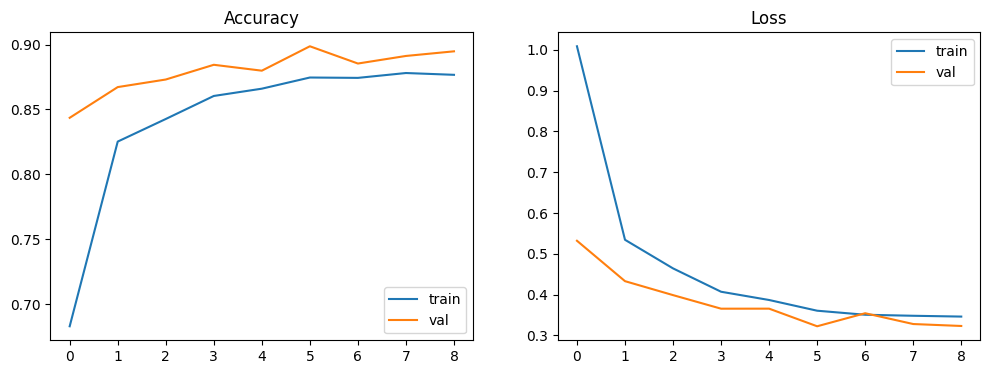


✅ Best model saved as plant_disease_model.keras


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: Class weights (from your actual Day 1 train counts,
# in the same order as class_names — verify this matches!)
# ============================================================
train_counts = [
    697,   # Pepper__bell___Bacterial_spot
    1034,  # Pepper__bell___healthy
    700,   # Potato___Early_blight
    700,   # Potato___Late_blight
    106,   # Potato___healthy
    1488,  # Tomato_Bacterial_spot
    700,   # Tomato_Early_blight
    1336,  # Tomato_Late_blight
    666,   # Tomato_Leaf_Mold
    1239,  # Tomato_Septoria_leaf_spot
    1173,  # Tomato_Spider_mites_Two_spotted_spider_mite
    982,   # Tomato__Target_Spot
    2246,  # Tomato__Tomato_YellowLeaf__Curl_Virus
    261,   # Tomato__Tomato_mosaic_virus
    1113,  # Tomato_healthy
]

assert len(train_counts) == len(class_names), "Mismatch! Recheck order against your Day 1 class_names list."

total = sum(train_counts)
num_classes = len(class_names)
class_weight = {i: total / (num_classes * c) for i, c in enumerate(train_counts)}
print("Class weights:", class_weight)
# Potato_healthy should have the highest weight (~9x), Tomato_YellowLeaf_Curl the lowest (~0.4x)

# ============================================================
# STEP 2: Build model (frozen MobileNetV2 backbone + new head)
# ============================================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

# ============================================================
# STEP 3: Compile
# ============================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# STEP 4: Callbacks + Train
# ============================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ModelCheckpoint('plant_disease_model.keras', save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight
)

# ============================================================
# STEP 5: Plot accuracy & loss
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()

plt.savefig('training_history.png')
plt.show()

print("\n✅ Best model saved as plant_disease_model.keras")

98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.8945 - loss: 0.3415

Test Accuracy: 0.8945
Test Loss: 0.3415

Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot      0.961     0.974     0.967       151
                     Pepper__bell___healthy      0.986     0.982     0.984       223
                      Potato___Early_blight      0.993     0.960     0.976       150
                       Potato___Late_blight      0.928     0.940     0.934       150
                           Potato___healthy      0.767     0.958     0.852        24
                      Tomato_Bacterial_spot      0.872     0.916     0.893       320
                        Tomato_Early_blight      0.848     0.633     0.725       150
                         Tomato_Late_blight      0.919     0.864     0.890       287
                           Tomato_Leaf_Mold      0.701     0.910     0.792       144
         

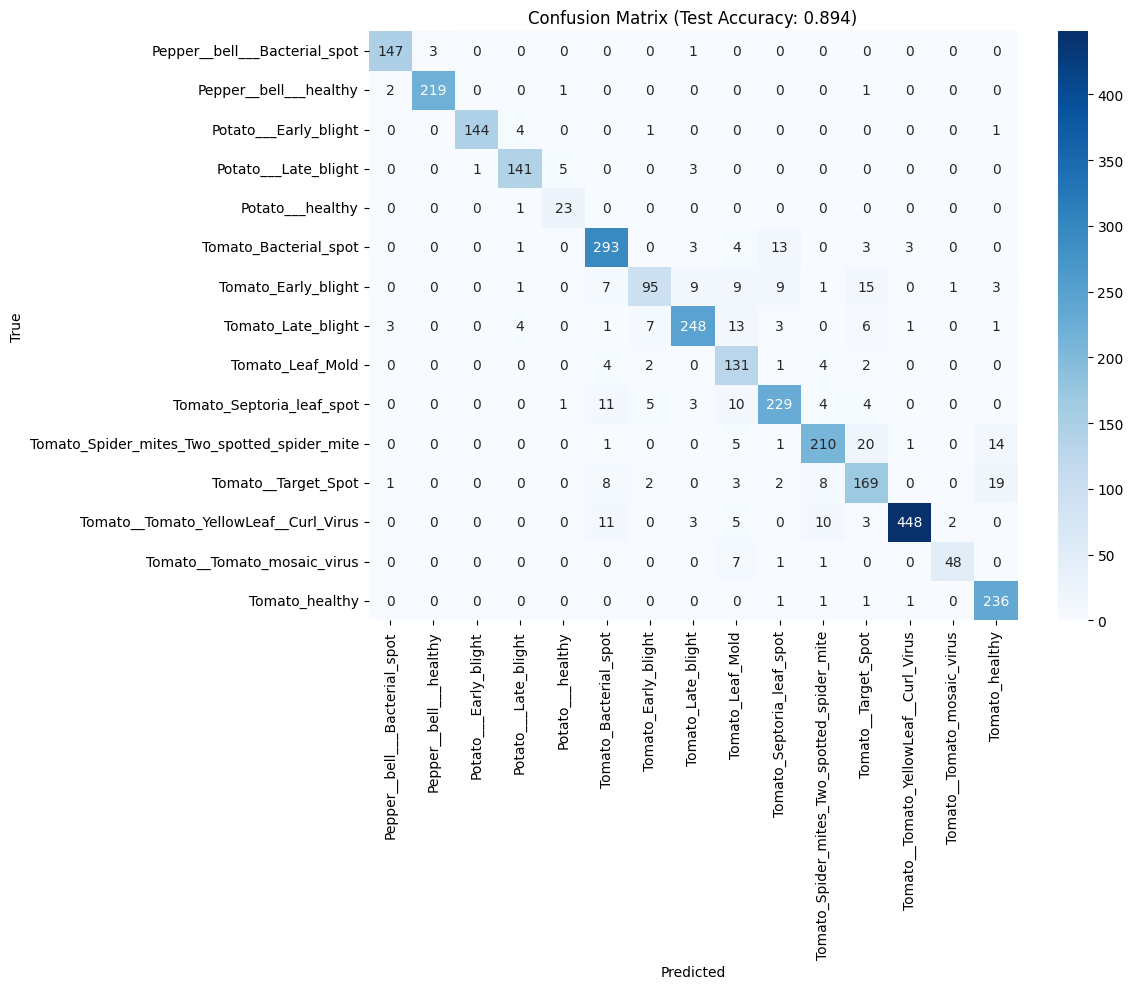

In [3]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the BEST saved model (not whatever's in memory from epoch 9)
best_model = tf.keras.models.load_model('plant_disease_model.keras')

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions and true labels for detailed metrics
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Precision, Recall, F1 per class
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title(f'Confusion Matrix (Test Accuracy: {test_acc:.3f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()